# GISLR · Stage 1 — architecture training

**Pipeline stage** for GISLR: shared feature caches → one training run per (architecture,
subset) → registry run folders → canonical-eval handoff. Replaces the four
`gislr.1.model.{gru,lstm,bilstm,cnn1d}.ipynb` notebooks, which differed only in an
architecture-identity block.

**Why one notebook.** "All else identical" is the entire premise of both the architecture
comparison (TODO §4) and the subset ablations (TODO §3.1) — a run whose batch size or LR
quietly differs from its comparators is not a benchmark, it is noise. Four files each carrying
their own `HYP` dict made that guarantee a manual chore, and the drift showed up in the docs
before it showed up in the code (README described batch 512 / lr 1e-3 long after the notebooks
moved to 1024 / 1.414e-3).

**Hyperparameters live in a file, not in a cell.**
[`src/config/gislr.training.json`](config/gislr.training.json) is the single source of truth,
read at run time by `sb.recognize.config`. Every architecture inherits the `shared` block;
an architecture can deviate only by naming a key in its own `overrides`, which §2 prints
alongside the resolved values — so a deviation is visible rather than something you diff four
files to find. Overriding a key that isn't in `shared` is a hard error, so a typo can't
masquerade as a tuned setting.

**Artifacts produced**

| artifact | path |
|---|---|
| per-subset feature caches (shared by every architecture) | `data/cache/gislr/features/{train,val}_<tag>_{data,offsets}.npy` |
| run-dir pointer per (arch, subset) — drives auto-resume | `data/cache/runs/gislr_<arch>_<tag>.txt` |
| registry run folder, one per training start | `data/models/<run_id>/` (run_id = epoch seconds) |
| — the run record (schema: README.md § "meta.json schema") | `data/models/<run_id>/meta.json` |
| — checkpoints (gitignored) | `data/models/<run_id>/{best,last}.pt` |
| — learning curves, per-epoch history, landmark indices | `data/models/<run_id>/assets/` |
| queryable run index (rebuild after evals) | `data/models/index.csv` |

**Resumability** — cache builds skip existing files and write atomically; training auto-resumes
an *interrupted* run from `last.pt` (checkpoint + `meta.json` + `assets/history.json` written
every epoch, early-stopping counter and LR-scheduler state included) via its pointer file. A
**finished** run is never reused: re-running an architecture section starts a fresh
epoch-seconds run folder per subset. An interrupt never forces a full rerun.

**Cell independence** — every section re-reads the config from disk and resolves its runs
through the registry's pointer files, so any single architecture section can be re-run on its
own after §1, with no dependency on the others having run.

**Design decisions**

- All reusable logic is in `modules/model/` — `architectures.py` is the single model-class
  definition, shared with `modules/scripts/evaluate.py`, so state_dicts can never drift.
- Training reports through **one progress bar per run** (batch progress, losses, LR, plateau
  counter in the same bar) — no nested bars, no per-epoch print spam.
- Feature caches are built **once** in §3 and reused by all four architectures; they depend on
  (subset, coords) only, never on the model.
- **Training only.** Evaluation, export and Kaggle submission are stage 2, in
  [`gislr.2.models.evaluation.ipynb`](gislr.2.models.evaluation.ipynb).

**Kernel requirements**: project `.venv`, CWD = `src/`, CUDA GPU.

**Phonology arms (§8b–§8e, TODO §3.9, added 2026-09-25).** `gru_phono`, `gru_phono_raw`, `bilstm_phono`: the ASL phonological parameters from `docs/reports/sign-patterns.md`, fed through a per-frame, shoulder-normalized front-end. Run order: §4 (builds the `PH_55/xyz` and `ME_134/xyz` caches), §8b, §8c, §8d (feature importance + which arm wins), then §8e.

## 1. Setup

Imports and paths only — **no hyperparameters here**. They come from
`src/config/gislr.training.json` via `sb.recognize.config.load_config()`, which every later
section calls itself.

In [3]:
# ============================================================
# Setup — imports and resolved paths (hyperparameters come from the config)
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sb.core.subsets import get_subset
from sb.recognize import (
    ARCHS,
    comparison_row,
    load_config,
    save_learning_curves,
    subset_tag,
    train_from_config,
)
# run records live in sb-mlops: the registry is readable without importing torch
from sb.mlops.registry import eval_command, load_meta, pointer_run_dir
from sb.core.paths import CACHE_DIR, MODELS_DIR, gislr_dir

# download the GISLR_Stratified dataset (never resolve_datasets() here —
# that would pull every dataset incl. POPSIGN raw video)
DATA_DIR = gislr_dir()


def ptr_key(arch: str, subset: str, coords: str) -> str:
    """Pointer-file key for one (arch, subset, coords) run — the registry's
    auto-resume handle, also used by the report/eval sections to find runs."""
    return f"gislr_{arch}_{subset_tag(subset, coords)}"


print(f"DATA_DIR   = {DATA_DIR}")
print(f"CACHE_DIR  = {CACHE_DIR}")
print(f"MODELS_DIR = {MODELS_DIR}")
print(f"architectures available: {', '.join(ARCHS)}")

DATA_DIR   = C:\Users\user2\.cache\kagglehub\datasets\bracu23101281\gislr-stratified\versions\1
CACHE_DIR  = C:\Users\user2\repository\data\cache
MODELS_DIR = C:\Users\user2\repository\registry\runs
architectures available: gru, lstm, gru_deep, bilstm, cnn1d, conv1d_transformer, gru_continuous, lstm_continuous, gru_phono, gru_phono_raw, bilstm_phono, gru_continuous_phono


## 2. Training configuration — the single source of truth

The whole grid, resolved, before anything trains. `overrides` is the column to watch: `—` means
the architecture uses the shared values exactly, which is what makes the comparison a
comparison. Anything else is a deliberate deviation and will show up in that run's `meta.json`.

To change a hyperparameter, edit [`src/config/gislr.training.json`](config/gislr.training.json)
and re-run this cell — no notebook cell holds these values.

In [4]:
# ============================================================
# Load + display the training config (edit src/config/gislr.training.json)
# ============================================================
cfg = load_config()

print(f"config : {cfg.path}")
print(f"dataset: {cfg.dataset} · regime: {cfg.regime} · coords: {cfg.coords}")
print(f"source recorded in meta.json: {cfg.source}\n")

summary = pd.DataFrame(cfg.summary())
with pd.option_context("display.width", 220, "display.max_columns", None):
    display(summary)

deviating = summary[summary["overrides"] != "—"]
if len(deviating):
    print("NOTE: these architectures deviate from the shared hyperparameters —")
    print("      their runs are not all-else-identical comparators:")
    display(deviating[["architecture", "overrides"]])
else:
    print("all architectures use the shared hyperparameters — runs are directly comparable")

planned = [(a, s) for a in cfg.architectures if cfg.enabled(a) for s in cfg.subsets_for(a)]
print(f"\nplanned: {len(planned)} runs = "
      + " + ".join(f"{a}×{len(cfg.subsets_for(a))}"
                   for a in cfg.architectures if cfg.enabled(a)))

config : C:\Users\user2\repository\experiments\recognition\configs\gislr.training.json
dataset: gislr · regime: v2-plateau-300 · coords: xy
source recorded in meta.json: gislr.1.models.training.ipynb



,architecture,enabled,coords,subsets,overrides,batch_size,lr,hidden_size,num_layers,dropout,weight_decay,epochs,grad_clip,lr_factor,lr_patience,es_patience,es_min_delta,frontend,mirror_p
0,gru,True,xy,"ME_126, ME_132, FP_118",—,1024,0.001414,256,2,0.3,0.0001,300,5.0,0.5,5,15,0.001,phono,0.0
1,lstm,True,xy,"ME_126, ME_132, FP_118",—,1024,0.001414,256,2,0.3,0.0001,300,5.0,0.5,5,15,0.001,phono,0.0
2,bilstm,True,xy,"ME_126, ME_132, FP_118",—,1024,0.001414,256,2,0.3,0.0001,300,5.0,0.5,5,15,0.001,phono,0.0
3,gru_deep,True,xy,"ME_126, ME_132, FP_118","hidden_size=384, num_layers=4",1024,0.001414,384,4,0.3,0.0001,300,5.0,0.5,5,15,0.001,phono,0.0
4,cnn1d,True,xy,"ME_126, ME_132, FP_118",num_layers=5,1024,0.001414,256,5,0.3,0.0001,300,5.0,0.5,5,15,0.001,phono,0.0
5,gru_phono,True,xyz,PH_55,—,1024,0.001414,256,2,0.3,0.0001,300,5.0,0.5,5,15,0.001,phono,0.0
6,gru_phono_raw,True,xyz,"PH_55, ME_134",frontend=phono+raw,1024,0.001414,256,2,0.3,0.0001,300,5.0,0.5,5,15,0.001,phono+raw,0.0
7,bilstm_phono,True,xyz,ME_134,frontend=phono+raw,1024,0.001414,256,2,0.3,0.0001,300,5.0,0.5,5,15,0.001,phono+raw,0.0


NOTE: these architectures deviate from the shared hyperparameters —
      their runs are not all-else-identical comparators:


,architecture,overrides
3,gru_deep,"hidden_size=384, num_layers=4"
4,cnn1d,num_layers=5
6,gru_phono_raw,frontend=phono+raw
7,bilstm_phono,frontend=phono+raw



planned: 19 runs = gru×3 + lstm×3 + bilstm×3 + gru_deep×3 + cnn1d×3 + gru_phono×1 + gru_phono_raw×2 + bilstm_phono×1


## 3. Canonical split check

Sanity-check GISLR_Stratified's fixed 80/20 split that every leaderboard run and
`sb.recognize.evaluate` share (75,581 train / 18,896 val). Purely diagnostic — the training
driver calls `get_canonical_split()` itself.

In [5]:
# ============================================================
# Canonical split sanity check — must match the leaderboard split exactly
# (the split itself is asserted inside sb.recognize.data.get_canonical_split)
# ============================================================
from sb.recognize import get_canonical_split, load_label_map

sign2idx = load_label_map(DATA_DIR)
train_split, val_split = get_canonical_split(DATA_DIR, sign2idx)
print(f"train {len(train_split)} / val {len(val_split)} · "
      f"{train_split['sign'].nunique()} classes · "
      f"val classes {val_split['sign'].nunique()}")
display(train_split.head(3))

train 75581 / val 18896 · 250 classes · val classes 250


,uid,sign,participant_id,sequence_id,split,npz_relpath,label
0,gislr_3504209118,grandma,28656,3504209118,train,train/gislr_3504209118.npz,99
1,gislr_597953520,sleep,37779,597953520,train,train/gislr_597953520.npz,199
2,gislr_3735480346,room,36257,3735480346,train,train/gislr_3735480346.npz,188


## 4. Feature caches — built once, shared by every architecture

One flat float32 array + offsets index per (split, subset, coords) under
`data/cache/gislr/features/<pipeline>/<key>/`, decoded from the GISLR_Stratified npz files once.
Caches depend on the *data*, never on the model, so all four architectures reuse them — this is
the section that used to be duplicated across four notebooks and rebuilt per notebook.

`<key>` is a **content address** (TODO §9.2): a hash of the pipeline + version, the subset's
actual index array, coords, the NaN policy and the dataset manifest. Editing an index list in
`subsets.py` therefore addresses a *different* directory instead of silently reusing the old
array under the same name, and `provenance.feature_cache_key` in each run's `meta.json` makes
"were these two runs trained on the same inputs?" a field comparison. Each directory carries a
`cache_key.json` sidecar naming what it holds.

Skip-if-exists and atomic; delete a directory to force a rebuild.


In [6]:
# ============================================================
# Build the feature caches every architecture will need
# (covers every (subset, coords) pair in the config)
# Safe to re-run — existing caches are skipped.
# ============================================================
from sb.recognize import build_subset_cache, get_canonical_split, load_label_map
from sb.recognize.features import base_v1, cache

cfg = load_config()
sign2idx = load_label_map(DATA_DIR)
train_split, val_split = get_canonical_split(DATA_DIR, sign2idx)

wanted = {(s, cfg.coords_for(a)) for a in cfg.architectures if cfg.enabled(a)
          for s in cfg.subsets_for(a)}
print(f"{len(wanted)} (subset, coords) cache pair(s) needed: "
      + ", ".join(f"{s}/{c}" for s, c in sorted(wanted)))

for name, coords in sorted(wanted):
    subset = get_subset(name)
    build_subset_cache(train_split, "train", subset, coords, DATA_DIR)
    build_subset_cache(val_split, "val", subset, coords, DATA_DIR)
    # the content address this (subset, coords) resolves to — the same value
    # each run records as provenance.feature_cache_key
    print(f"  {name}/{coords} -> {base_v1.PIPELINE}/"
          f"{base_v1.cache_key(subset, coords, DATA_DIR)}")

total_gb = sum(f.stat().st_size
               for f in cache.features_root("gislr").rglob("*_data.npy")) / 1e9
print(f"\ntotal feature-cache size on disk: {total_gb:.1f} GB")


5 (subset, coords) cache pair(s) needed: FP_118/xy, ME_126/xy, ME_132/xy, ME_134/xyz, PH_55/xyz
  FP_118/xy -> base_v1/85ba4bf196713928
  ME_126/xy -> base_v1/4ffb3148942dca48
  ME_132/xy -> base_v1/b94308e09d35b436
  ME_134/xyz -> base_v1/e266b312e6a1954a
  PH_55/xyz -> base_v1/f36545d67ec0ded2

total feature-cache size on disk: 124.7 GB


## 5. `StreamingGRU`

Unidirectional (causal) GRU — **the deployment
architecture**. Everything else in this notebook exists to be measured against it: the LSTM as a
cell-for-cell alternative, the BiLSTM as an upper bound it can never reach, the CNN as a
different inductive bias entirely.

Trains one run per subset in the config. **Re-runnable on its own**: this cell reloads the
config from disk and needs nothing from the other architecture sections. Finished runs are never
reused — re-running starts a fresh run folder per subset.

In [5]:
# ============================================================
# Train gru — hyperparameters from src/config/gislr.training.json
# (tunable here: SUBSETS override for a one-off; None = whatever the config says)
# ============================================================
ARCH = "gru"
SUBSETS = None   # e.g. ["ME_126"] to train just one, without editing the config

run_dirs_gru = train_from_config(ARCH, subsets=SUBSETS)

for name, rd in run_dirs_gru.items():
    print(f"  {name}: {rd.name}")

gru · regime v2-plateau-300 · coords xy · subsets ['ME_126', 'ME_132', 'FP_118']
  hyperparameters from gislr.training.json (shared, no overrides)


gislr/gru/me126-xy · run 1790352803:   0%|          | 0/300 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5b. `gru_deep` — depth/width diagnostic (TODO §4.1)

Same `StreamingGRU` class as §5, just deeper/wider (`hidden_size=384, num_layers=4` vs the
shared 256×2) via the config's `overrides` — **still streaming-viable**. This is the
"if the goal is a deployable model, depth should go into GRU/LSTM/CausalConv1D, not BiLSTM"
branch of TODO §4.1: it tests whether GRU capacity alone can close the gap to bilstm's 0.7569
without giving up causal inference.

Trains one run per subset in the config. **Re-runnable on its own**: this cell reloads the
config from disk and needs nothing from the other architecture sections. Finished runs are never
reused — re-running starts a fresh run folder per subset.


In [ ]:
# ============================================================
# Train gru_deep — hyperparameters from src/config/gislr.training.json
# (tunable here: SUBSETS override for a one-off; None = whatever the config says)
# ============================================================
ARCH = "gru_deep"
SUBSETS = None   # e.g. ["ME_126"] to train just one, without editing the config

run_dirs_gru_deep = train_from_config(ARCH, subsets=SUBSETS)

for name, rd in run_dirs_gru_deep.items():
    print(f"  {name}: {rd.name}")


gru_deep · regime v2-plateau-300 · coords xy · subsets ['ME_126', 'ME_132', 'FP_118']
  hyperparameters from gislr.training.json · OVERRIDES: {'hidden_size': 384, 'num_layers': 4}

[provenance] gislr/gru_deep/me126-xy UNCOMMITTED CODE -- this run will not be reproducible.
  dirty: packages/sb-synthesize/src/sb/synthesize/gloss/export_web.py
  commit on record: 2bc889ea308a1721ff324f825b38599e405396d8
  Commit src/modules + src/config before a run whose number you
  intend to cite.



gislr/gru_deep/me126-xy · run 1790333188:   0%|          | 0/300 [00:00<?, ?it/s]

me126-xy: EARLY STOP at epoch 72 — no val-acc gain > 0.001 for 15 epochs
me126-xy: DONE best_val_acc=0.7344 run_dir=C:\Users\user2\repository\registry\runs\1790333188


gislr/gru_deep/me132-xy · run 1790334584:   0%|          | 0/300 [00:00<?, ?it/s]

me132-xy: EARLY STOP at epoch 85 — no val-acc gain > 0.001 for 15 epochs
me132-xy: DONE best_val_acc=0.7335 run_dir=C:\Users\user2\repository\registry\runs\1790334584

[provenance] gislr/gru_deep/fp118-xy UNCOMMITTED CODE -- this run will not be reproducible.
  dirty: packages/sb-recognize/src/sb/recognize/label_merge.py
  commit on record: 67993c8345feee468d0b577ccb8611794d96b4b2
  Commit src/modules + src/config before a run whose number you
  intend to cite.



gislr/gru_deep/fp118-xy · run 1790336517:   0%|          | 0/300 [00:00<?, ?it/s]

fp118-xy: EARLY STOP at epoch 81 — no val-acc gain > 0.001 for 15 epochs
fp118-xy: DONE best_val_acc=0.7304 run_dir=C:\Users\user2\repository\registry\runs\1790336517
  ME_126: 1790333188
  ME_132: 1790334584
  FP_118: 1790336517


## 6. `StreamingLSTM`

Unidirectional (causal) LSTM — streaming-viable, and the
direct LSTM-vs-GRU comparison (TODO §4): identical hidden size, layers, readout and head, so the
recurrent cell is the only variable.

Trains one run per subset in the config. **Re-runnable on its own**: this cell reloads the
config from disk and needs nothing from the other architecture sections. Finished runs are never
reused — re-running starts a fresh run folder per subset.

In [ ]:
# ============================================================
# Train lstm — hyperparameters from src/config/gislr.training.json
# (tunable here: SUBSETS override for a one-off; None = whatever the config says)
# ============================================================
ARCH = "lstm"
SUBSETS = None   # e.g. ["ME_126"] to train just one, without editing the config

run_dirs_lstm = train_from_config(ARCH, subsets=SUBSETS)

for name, rd in run_dirs_lstm.items():
    print(f"  {name}: {rd.name}")

lstm · regime v2-plateau-300 · coords xy · subsets ['ME_126', 'ME_132', 'FP_118']
  hyperparameters from gislr.training.json (shared, no overrides)


gislr/lstm/me126-xy · run 1790338279:   0%|          | 0/300 [00:00<?, ?it/s]

me126-xy: EARLY STOP at epoch 96 — no val-acc gain > 0.001 for 15 epochs
me126-xy: DONE best_val_acc=0.7367 run_dir=C:\Users\user2\repository\registry\runs\1790338279


gislr/lstm/me132-xy · run 1790339908:   0%|          | 0/300 [00:00<?, ?it/s]

me132-xy: EARLY STOP at epoch 76 — no val-acc gain > 0.001 for 15 epochs
me132-xy: DONE best_val_acc=0.7261 run_dir=C:\Users\user2\repository\registry\runs\1790339908


gislr/lstm/fp118-xy · run 1790341214:   0%|          | 0/300 [00:00<?, ?it/s]

fp118-xy: EARLY STOP at epoch 75 — no val-acc gain > 0.001 for 15 epochs
fp118-xy: DONE best_val_acc=0.7260 run_dir=C:\Users\user2\repository\registry\runs\1790341214
  ME_126: 1790338279
  ME_132: 1790339908
  FP_118: 1790341214


## 7. `BiLSTM`

Bidirectional LSTM — an **offline-only accuracy reference,
never a deployment candidate**. Its backward pass reads future frames, which the streaming
deployment target forbids (README § Constraints). It exists to price how much accuracy causality
costs: the gap between it and `StreamingLSTM` is that price, since the two differ only in
direction.

Trains one run per subset in the config. **Re-runnable on its own**: this cell reloads the
config from disk and needs nothing from the other architecture sections. Finished runs are never
reused — re-running starts a fresh run folder per subset.

In [ ]:
# ============================================================
# Train bilstm — hyperparameters from src/config/gislr.training.json
# (tunable here: SUBSETS override for a one-off; None = whatever the config says)
# ============================================================
ARCH = "bilstm"
SUBSETS = None   # e.g. ["ME_126"] to train just one, without editing the config

run_dirs_bilstm = train_from_config(ARCH, subsets=SUBSETS)

for name, rd in run_dirs_bilstm.items():
    print(f"  {name}: {rd.name}")

bilstm · regime v2-plateau-300 · coords xy · subsets ['ME_126', 'ME_132', 'FP_118']
  hyperparameters from gislr.training.json (shared, no overrides)


gislr/bilstm/me126-xy · run 1790347646:   0%|          | 0/300 [00:00<?, ?it/s]

me126-xy: EARLY STOP at epoch 77 — no val-acc gain > 0.001 for 15 epochs
me126-xy: DONE best_val_acc=0.7503 run_dir=C:\Users\user2\repository\registry\runs\1790347646


gislr/bilstm/me132-xy · run 1790349689:   0%|          | 0/300 [00:00<?, ?it/s]

me132-xy: EARLY STOP at epoch 65 — no val-acc gain > 0.001 for 15 epochs
me132-xy: DONE best_val_acc=0.7416 run_dir=C:\Users\user2\repository\registry\runs\1790349689


gislr/bilstm/fp118-xy · run 1790351435:   0%|          | 0/300 [00:00<?, ?it/s]

## 8. `CausalConv1D`

Dilated causal Conv1d stack — streaming-viable, and the
first step toward the 1st-place 1D-CNN + Transformer port. Every conv is left-padded so frame *t*
never sees *t+1*, and normalization is per-frame LayerNorm rather than BatchNorm (whose
statistics would mix future frames into past ones).

**Note**: this architecture currently scores ~0.54 against ~0.75 for the recurrent models — a
~20-point gap that is an architecture/hyperparameter problem specific to it, not the shared
~73% plateau (TODO §7).

Trains one run per subset in the config. **Re-runnable on its own**: this cell reloads the
config from disk and needs nothing from the other architecture sections. Finished runs are never
reused — re-running starts a fresh run folder per subset.

In [ ]:
# ============================================================
# Train cnn1d — hyperparameters from src/config/gislr.training.json
# (tunable here: SUBSETS override for a one-off; None = whatever the config says)
# ============================================================
ARCH = "cnn1d"
SUBSETS = None   # e.g. ["ME_126"] to train just one, without editing the config

run_dirs_cnn1d = train_from_config(ARCH, subsets=SUBSETS)

for name, rd in run_dirs_cnn1d.items():
    print(f"  {name}: {rd.name}")

## 8b. `gru_phono` — phonology features only (TODO §3.9)

`docs/reports/sign-patterns.md` §7–§8 found that per-frame **ASL phonological parameters**
(handshape, palm orientation, location relative to the face and body) carry sign identity. With
no training, templates on them reach 38.8–41.6% top-1. This arm puts them in front of the
deployment model.

- **Model:** `PhonoGRU` = the same `StreamingGRU` behind a **non-learned, per-frame
  `PhonologyFrontend`** (`sb.recognize.architectures`).
- **Normalization:** every frame is centred on the mid-shoulder point and divided by that frame's
  shoulder width, so framing, distance and aspect ratio drop out. That is the failure the live
  camera test hit (`live-streaming-gap.md`).
- **Features:** 41 per hand (handshape 25, orientation 6, location 9, present 1) + 2 elbow angles =
  **84 per frame**. The left hand is computed mirrored.
- **Input:** subset `PH_55` (both hands, upper-body pose, 5 face anchors), `xyz`, because finger
  angles use hand depth.
- **Streaming:** the front-end is per-frame, so the model is still causal and streams exactly like
  `gru`. `RecurrentSession` matches the batch forward to 2e-5 (checked 2026-09-25).
- **Continuous port:** a continuous version already exists as `gru_continuous_phono`. It is the §12.3
  recipe with the same front-end, so a win here ports to continuous signing by changing the arch
  key.
- **All else equal:** same regime and every `shared` hyperparameter as `gru`. `mirror_p` stays 0 (no
  mirror augmentation), like every existing run.

**Re-runnable on its own**; needs §4's `PH_55/xyz` cache.

In [5]:
# ============================================================
# Train gru_phono — hyperparameters from src/config/gislr.training.json
# (tunable here: SUBSETS override for a one-off; None = whatever the config says)
# ============================================================
ARCH = "gru_phono"
SUBSETS = None   # config: ["PH_55"]

run_dirs_gru_phono = train_from_config(ARCH, subsets=SUBSETS)

for name, rd in run_dirs_gru_phono.items():
    print(f"  {name}: {rd.name}")

gru_phono · regime v2-plateau-300 · coords xyz · subsets ['PH_55']
  hyperparameters from gislr.training.json (shared, no overrides)


gislr/gru_phono/ph55 · run 1790352947:  14%|#3        | 41/300 [00:00<?, ?it/s]

ph55: resumed at epoch 41, best 0.6931, plateau 3/15
ph55: EARLY STOP at epoch 61 — no val-acc gain > 0.001 for 15 epochs
ph55: DONE best_val_acc=0.7010 run_dir=C:\Users\user2\repository\registry\runs\1790352947
  PH_55: 1790352947


## 8c. `gru_phono_raw` — phonology + landmark subsets (TODO §3.9)

Same `PhonoGRU` class with front-end mode `phono+raw`: the 84 phonology features plus the subset's
**shoulder-normalized** `(x, y)` per landmark. Two subsets answer "does this combine with the
subset work":

| subset | adds on top of the phonology features | features / frame |
|---|---|---|
| `PH_55` | hand + upper-pose + 5 face-anchor coordinates ("phonology + hands") | 194 |
| `ME_134` | ME_132's coordinates (lips, eyes/nose, hands, pose) + chin/forehead | 352 |

Compare with `gru` on ME_132/xy (**0.7517**, canonical) and with §8b. Note that `gru`'s raw input is
*not* shoulder-normalized. **Re-runnable on its own**; needs §4's `PH_55/xyz` and `ME_134/xyz`
caches.

In [6]:
# ============================================================
# Train gru_phono_raw — hyperparameters from src/config/gislr.training.json
# (tunable here: SUBSETS override for a one-off; None = whatever the config says)
# ============================================================
ARCH = "gru_phono_raw"
SUBSETS = None   # config: ["PH_55", "ME_134"]

run_dirs_gru_phono_raw = train_from_config(ARCH, subsets=SUBSETS)

for name, rd in run_dirs_gru_phono_raw.items():
    print(f"  {name}: {rd.name}")

gru_phono_raw · regime v2-plateau-300 · coords xyz · subsets ['PH_55', 'ME_134']
  hyperparameters from gislr.training.json · OVERRIDES: {'frontend': 'phono+raw'}


gislr/gru_phono_raw/ph55 · run 1790354810:   0%|          | 0/300 [00:00<?, ?it/s]

ph55: EARLY STOP at epoch 49 — no val-acc gain > 0.001 for 15 epochs
ph55: DONE best_val_acc=0.7429 run_dir=C:\Users\user2\repository\registry\runs\1790354810


gislr/gru_phono_raw/me134 · run 1790355555:   0%|          | 0/300 [00:00<?, ?it/s]

me134: EARLY STOP at epoch 62 — no val-acc gain > 0.001 for 15 epochs
me134: DONE best_val_acc=0.7631 run_dir=C:\Users\user2\repository\registry\runs\1790355555
  PH_55: 1790354810
  ME_134: 1790355555


## 8d. Which features carry the model — permutation importance per feature group (TODO §3.9)

For every **finished** §8b/§8c run: validation accuracy with one front-end feature group at a time
replaced by another clip's values (`sb.recognize.phonology_eval.feature_group_importance`, 3
repeats). The groups:

- per hand as MediaPipe labels it (`r_` / `l_`): `handshape`, `orientation`, `location`, `present`;
- `elbows`;
- and, for `phono+raw`, the raw coordinates by region: `raw_hands`, `raw_pose`, `raw_face`.

A large drop means the model depends on the group; ~0 means the rest already covers it. No
training; about a minute per run on the GPU. The table and figure go to each run's `assets/`. The
cell also names the best §8b/§8c arm, which §8e should use.


gru_phono · PH_55 · run 1790352947 · val acc 0.7010 · accuracy drop when a group is permuted:


,group,n_features,drop,drop_std
1,r_handshape,25,0.5176,0.0019
2,r_orientation,6,0.4370,0.0018
3,r_location,9,0.4261,0.0012
5,l_handshape,25,0.3894,0.0013
7,l_location,9,0.3270,0.0017
6,l_orientation,6,0.3137,0.0024
4,r_present,1,0.1020,0.0019
8,l_present,1,0.0639,0.0008
9,elbows,2,0.0248,0.0013


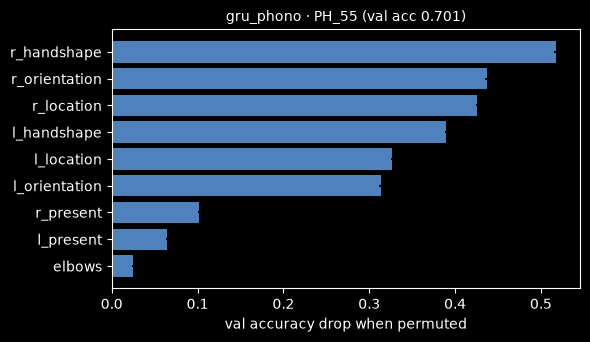


gru_phono_raw · PH_55 · run 1790354810 · val acc 0.7429 · accuracy drop when a group is permuted:


,group,n_features,drop,drop_std
11,raw_hands,84,0.6546,0.0009
1,r_handshape,25,0.4697,0.0016
5,l_handshape,25,0.3456,0.0020
2,r_orientation,6,0.2534,0.0026
6,l_orientation,6,0.1643,0.0001
7,l_location,9,0.1520,0.0010
3,r_location,9,0.1325,0.0011
10,raw_face,10,0.0887,0.0022
12,raw_pose,16,0.0428,0.0014
9,elbows,2,0.0308,0.0016


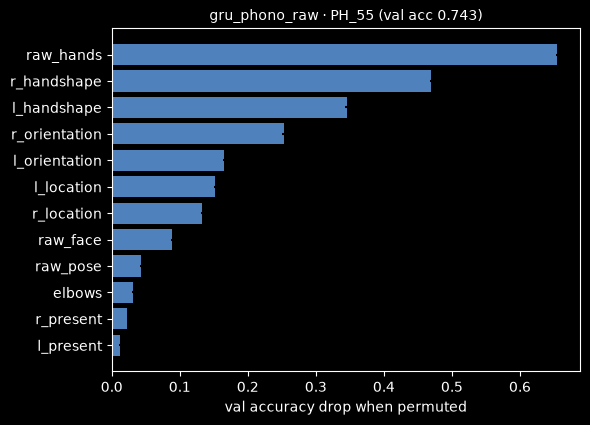


gru_phono_raw · ME_134 · run 1790355555 · val acc 0.7632 · accuracy drop when a group is permuted:


,group,n_features,drop,drop_std
11,raw_hands,84,0.6808,0.0026
1,r_handshape,25,0.4427,0.0030
5,l_handshape,25,0.3404,0.0003
2,r_orientation,6,0.2138,0.0022
10,raw_face,156,0.1828,0.0026
6,l_orientation,6,0.1452,0.0020
12,raw_pose,28,0.0626,0.0017
7,l_location,9,0.0522,0.0016
3,r_location,9,0.0405,0.0010
9,elbows,2,0.0204,0.0003


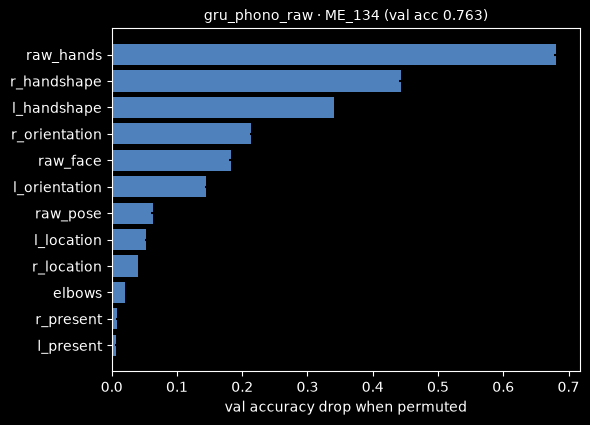


best phonology arm: gru_phono_raw on ME_134 (training-loop best val acc 0.7631)
-> bilstm_phono in the config already matches; run §8e


In [7]:
# ============================================================
# Feature-group permutation importance for every finished phonology run
# (tunables: N_REPEATS, PHONO_ARCHS)
# ============================================================
import torch
from sb.recognize.phonology_eval import feature_group_importance, load_phono_run, val_loader

N_REPEATS = 3
PHONO_ARCHS = ("gru_phono", "gru_phono_raw")

cfg = load_config()
dev = torch.device("cuda")
arms = []
for arch in PHONO_ARCHS:
    for name in cfg.subsets_for(arch):
        rd = pointer_run_dir(ptr_key(arch, name, cfg.coords_for(arch)))
        if rd is None or not load_meta(rd)["training"]["finished"]:
            print(f"{arch}/{name}: not finished yet -- skipped")
            continue
        arms.append((arch, name, rd))

for arch, name, rd in arms:
    out = rd / "assets" / "feature_group_importance.csv"
    if not out.exists():
        model, ck = load_phono_run(rd, dev)
        imp = feature_group_importance(model, val_loader(ck), n_repeats=N_REPEATS)
        imp.to_csv(out, index=False)
    imp = pd.read_csv(out)
    base = imp.acc.iat[0]
    top = imp.iloc[1:].sort_values("drop", ascending=False)
    print(f"\n{arch} · {name} · run {rd.name} · val acc {base:.4f} · accuracy drop when a group is permuted:")
    display(top[["group", "n_features", "drop", "drop_std"]].round(4))
    fig, ax = plt.subplots(figsize=(6, 0.28 * len(top) + 1))
    ax.barh(top.group, top["drop"], xerr=top.drop_std, color="#4f81bd")
    ax.invert_yaxis()
    ax.set_xlabel("val accuracy drop when permuted")
    ax.set_title(f"{arch} · {name} (val acc {base:.3f})", fontsize=10)
    fig.tight_layout()
    fig.savefig(rd / "assets" / "feature_group_importance.png", dpi=120)
    plt.show()

if arms:
    best = max(arms, key=lambda a: load_meta(a[2])["metrics"]["train_val_acc"])
    print(f"\nbest phonology arm: {best[0]} on {best[1]} "
          f"(training-loop best val acc {load_meta(best[2])['metrics']['train_val_acc']:.4f})")
    b_over = cfg.overrides_for("bilstm_phono").get("frontend", cfg.shared.get("frontend"))
    want = "phono+raw" if best[0] == "gru_phono_raw" else "phono"
    if cfg.subsets_for("bilstm_phono") != [best[1]] or b_over != want:
        print(f"-> set bilstm_phono to subsets [{best[1]!r}] + frontend {want!r} in "
              "gislr.training.json before running §8e")
    else:
        print("-> bilstm_phono in the config already matches; run §8e")

## 8e. `bilstm_phono` — the best model regardless of streaming (TODO §3.9)

The **offline-only** `BiLSTM` (bidirectional, never deployable) behind the same front-end. It tests
how far the phonology features go when causality is not a constraint.

- **Why BiLSTM:** it holds the historical accuracy record in this repo (0.7569, retired split).
- **Why not the 1st-place `conv1d_transformer`:** it has collapsed at epoch 15 on both attempts
  (TODO §4.2).
- **Before running:** the config defaults to `phono+raw` on `ME_134`, the expected winner. If §8d
  names another arm, change `bilstm_phono`'s `subsets` / `overrides.frontend` in the config first.
- **Compare with:** `bilstm` (ME_132/xy) and the §8b/§8c GRUs; the gap between them is the price of
  streaming with these features.

In [ ]:
# ============================================================
# Train bilstm_phono — hyperparameters from src/config/gislr.training.json
# (tunable here: SUBSETS override for a one-off; None = whatever the config says)
# ============================================================
ARCH = "bilstm_phono"
SUBSETS = None   # config default: ["ME_134"]; follow §8d's recommendation

run_dirs_bilstm_phono = train_from_config(ARCH, subsets=SUBSETS)

for name, rd in run_dirs_bilstm_phono.items():
    print(f"  {name}: {rd.name}")

bilstm_phono · regime v2-plateau-300 · coords xyz · subsets ['ME_134']
  hyperparameters from gislr.training.json · OVERRIDES: {'frontend': 'phono+raw'}


gislr/bilstm_phono/me134 · run 1790356714:   0%|          | 0/300 [00:00<?, ?it/s]

## 8f. `gru_phono130` — phonological features only, in sequence (TODO §3.10)

The user's request (2026-09-26): "train a model that only understands the phonological features and the
sequence of it". No raw coordinate reaches this model.

- **Input:** the 130 per-frame features of `sb.recognize.phonology`, computed from **all 543 landmarks**
  (no subset): handshape 50, orientation 12, location 29, contact 2, movement 15, hand arrangement 10,
  non-manual 10, presence 2. Anchored at the mid-shoulder point, mirrored so +x is the dominant side,
  lengths in shoulder widths, fixed unit scaling (angles /90, speeds ×20), clipped to ±10.
- **Pipeline:** `phono130_v1`, precomputed per clip (the `ArchSpec` names it, so the driver and
  `sb-evaluate` pick it up; `FULL_543/xyz` in the config only addresses the cache). Cache already built
  (2026-09-26, 1.9 GB, key `157b4b1550f45acf`).
- **Model:** the same `StreamingGRU` and `shared` regime as `gru`, 758k parameters (fewer than `gru`'s
  861k). The GRU reads the features **in order**, so it can use what `gislr.0.dataset.phonology-features`
  §11 found templates cannot: order carries information (shuffling at equal size costs up to 12.6 points
  of 1-NN, reversing 18–20), but fixed segments and DTW cannot exploit it.
- **Streaming:** checked 2026-09-26 — `RecurrentSession` = batch forward to 1.3e-6. Two values are session
  constants (dominant hand, shoulder width), which a live app calibrates once.
- **Baselines:** no training, the same features reach 41.4% (template) / 54.3% (1-NN). Trained:
  `gru_phono_raw` ME_134 **0.7632**, `gru` ME_132 **0.7517**.

In [ ]:
# ============================================================
# Train gru_phono130 — hyperparameters from experiments/recognition/configs/gislr.training.json
# (tunable here: SUBSETS override for a one-off; None = whatever the config says)
# ============================================================
ARCH = "gru_phono130"
SUBSETS = None   # config: ["FULL_543"] (cache address only; the features are phono130_v1)

run_dirs_gru_phono130 = train_from_config(ARCH, subsets=SUBSETS)

for name, rd in run_dirs_gru_phono130.items():
    print(f"  {name}: {rd.name}")

## 8g. `bilstm_phono130` — the offline ceiling for the same input (TODO §3.10)

The **offline-only** `BiLSTM` on the same 130 features: how much the causal constraint costs on
phonological input. Run after §8f; not deployable.

In [ ]:
# ============================================================
# Train bilstm_phono130 — hyperparameters from experiments/recognition/configs/gislr.training.json
# ============================================================
ARCH = "bilstm_phono130"
SUBSETS = None   # config: ["FULL_543"]

run_dirs_bilstm_phono130 = train_from_config(ARCH, subsets=SUBSETS)

for name, rd in run_dirs_bilstm_phono130.items():
    print(f"  {name}: {rd.name}")

## 9. Comparison across architectures

Reads every run **from disk** via the registry pointer files, so it works in a fresh kernel
without re-running any training section, and reports whatever exists so far.

`train_val_acc` here is the training loop's own best val accuracy — provisional. Leaderboard
comparisons require the canonical per-class eval (§10), which is also what
`gislr.2.models.evaluation.ipynb` builds its confusion matrices from.

In [ ]:
# ============================================================
# Learning curves + cross-architecture comparison table
# (tunables: REPORT_ARCHS, SHOW_CURVES) — loads runs via pointer files
# ============================================================
REPORT_ARCHS = None    # None = every architecture in the config
SHOW_CURVES = True     # per-run learning-curve figures (saved into each run's assets/)

cfg = load_config()
archs = REPORT_ARCHS or cfg.architectures

rows = []
for arch in archs:
    coords = cfg.coords_for(arch)
    for name in cfg.subsets_for(arch):
        rd = pointer_run_dir(ptr_key(arch, name, coords))
        if rd is None:
            continue
        if SHOW_CURVES:
            save_learning_curves(rd, title=f"{arch} · {name}/{coords} · run {rd.name}")
            plt.show()
        rows.append({"architecture": arch, **comparison_row(rd)})

if rows:
    table = (pd.DataFrame(rows)
             .sort_values("train_val_acc", ascending=False)
             .reset_index(drop=True))
    with pd.option_context("display.width", 220, "display.max_columns", None):
        display(table)

    # an interrupted run is not a result — exclude it from "best" rather than
    # letting a partially-trained model look like a bad architecture
    unfinished = table[~table["finished"]]
    if len(unfinished):
        print("INTERRUPTED runs (still training or stopped early by hand) — "
              "not comparable, excluded from the summary below:")
        display(unfinished[["architecture", "subset", "run_id", "epochs",
                            "train_val_acc"]])

    done = table[table["finished"]]
    if len(done):
        print("\nbest FINISHED run per architecture:")
        display(done.sort_values("train_val_acc", ascending=False)
                .groupby("architecture", as_index=False).first()
                .sort_values("train_val_acc", ascending=False)
                [["architecture", "subset", "coords", "n_params",
                  "train_val_acc", "eval_status"]])
else:
    print("no runs yet — train an architecture in §5-§8 first")

## 10. Canonical per-class eval handoff

Prints the exact `modules/scripts/evaluate.py` command per run — **run those yourself**; this
notebook never evaluates. The eval promotes a run's `meta.json` to `eval_status: "canonical"` and
writes `assets/val_predictions.npz` (the input to every confusion matrix downstream).

**This is the last stage here.** Leaderboard, confusion matrices, TFLite export and Kaggle
submission all live in [`gislr.2.models.evaluation.ipynb`](gislr.2.models.evaluation.ipynb) —
whose §3 can also run this backfill in-process, if you'd rather not paste commands.

In [ ]:
# ============================================================
# Canonical per-class eval handoff (tunable: DOC_ARCHS)
# meta.json is already written every epoch by the training driver — this cell
# only prints the eval + index-rebuild commands for the user.
# ============================================================
DOC_ARCHS = None    # None = every architecture in the config

cfg = load_config()
archs = DOC_ARCHS or cfg.architectures

print("=== canonical per-class eval — run these from the repo root (user) ===")
n = 0
for arch in archs:
    coords = cfg.coords_for(arch)
    for name in cfg.subsets_for(arch):
        rd = pointer_run_dir(ptr_key(arch, name, coords))
        if rd is None:
            continue
        finished = load_meta(rd)["training"]["finished"]
        print(f"\n# {arch} · {name}/{coords} · run {rd.name}"
              + ("" if finished else "   (WAIT: training incomplete)"))
        print(eval_command(rd))
        n += 1

if n:
    print("\nafterwards, rebuild the index:")
    print(".venv/Scripts/python.exe src/modules/scripts/build_model_index.py")
    print("\nor run gislr.2.models.evaluation.ipynb §3, which backfills every "
          "pending run in-process.")
else:
    print("no runs yet — train an architecture in §5-§8 first")